In [85]:
# Required by PythonicDISORT
import numpy as np
import scipy as sc
from numpy.polynomial.legendre import Legendre
from math import pi
from scipy import integrate
from warnings import warn
import PythonicDISORT


In [86]:
# Required only in this notebook for tests and exposition
import autograd as ag
import autograd.numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants

In [87]:
# Defining the optical properties
mua = 0.003
mus = 0.03
mut = mua + mus
omega = mus / (mua + mus)
omega_arr = np.array([omega]) 

In [88]:
# Defining the source
mu0 = 1  # Cosine of solar zenith angle (directly downwards)
I0 = 1 / mu0  # Intensity of direct beam
phi0 = pi  # Azimuthal angle of direct beam, does not matter when mu0=1

In [113]:
# Pythoic disort uses optical depth instead of depth, this is defined as depth multiplied by the sum of the mua and mus
# Below, I am just defining that there is a single layer
# If I wanted multiple layers with different thicknesses, I would define is as [0.5,5,5.5,8,...]
length = 198
tau_arr = length * mut
NLayers = 1

In [114]:
# Number of discrete angular streams
NQuad = 32
# Henyey-Greenstein asymmetry parameter
g = 0.8
# Number of available Legendre coefficients
NLeg_all = 64
Leg_coeffs_all = g ** np.arange(64)  # Henyey-Greenstein phase function
# Optional (used)
f_arr = Leg_coeffs_all[NQuad]  # For delta-M scaling (improves accuracy, especially for fluxes)
NT_cor = True  # Turn on NT corrections (improves accuracy of intensity field; no effect on fluxes)


In [115]:
# Optional (unused)
NLeg = None
NFourier = None
b_pos = 0
b_neg = 0
only_flux = False
BDRF_Fourier_modes = []
s_poly_coeffs = np.array([[]])
use_banded_solver_NLayers=10
autograd_compatible=False

In [116]:
# Call pydisort function
mu_arr, flux_up, flux_down, u0, u = PythonicDISORT.pydisort(
    tau_arr, omega_arr,
    NQuad,
    Leg_coeffs_all,
    mu0, I0, phi0,
    f_arr=f_arr,
    NT_cor=NT_cor
)

In [117]:
R_disort = flux_up(0) / (I0 * mu0)
F_down_diffuse_bottom, F_down_direct_bottom = flux_down(tau_arr) 
T_disort = (F_down_diffuse_bottom + F_down_direct_bottom) / (I0 * mu0)

In [121]:
print(f"R_disort = {R_disort:.6f}")
print(f"T_disort = {T_disort:.6f}")
print(f"R+T = {R_disort + T_disort:.6f} (absorbance = {1 - R_disort - T_disort:.6f})")

R_disort = 0.139972
T_disort = 0.254625
R+T = 0.394597 (absorbance = 0.605403)


In [119]:
tau_test_arr = np.linspace(0, tau_arr, 100)
real_distance_test_arr = tau_test_arr / mut

F_up = flux_up(tau_test_arr)

F_down_diffuse, F_down_direct = flux_down(tau_test_arr)

F_down_total = F_down_diffuse + F_down_direct

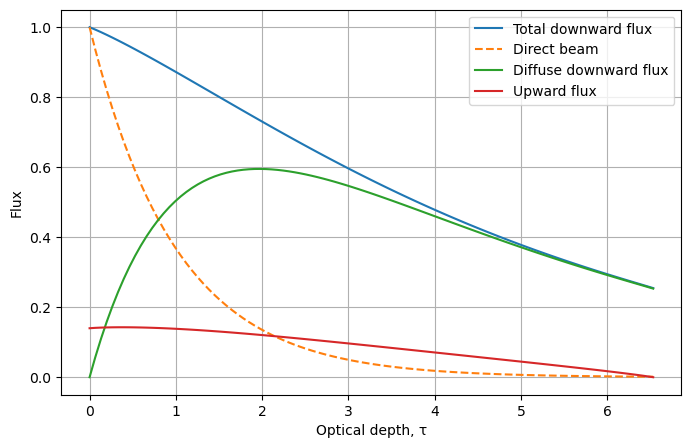

In [120]:
plt.figure(figsize=(8,5))

plt.plot(tau_test_arr, F_down_total, label="Total downward flux")
plt.plot(tau_test_arr, F_down_direct, "--", label="Direct beam")
plt.plot(tau_test_arr, F_down_diffuse, label="Diffuse downward flux")
plt.plot(tau_test_arr, F_up, label="Upward flux")

plt.xlabel("Optical depth, τ")
plt.ylabel("Flux")
plt.legend()
plt.grid()

plt.show()

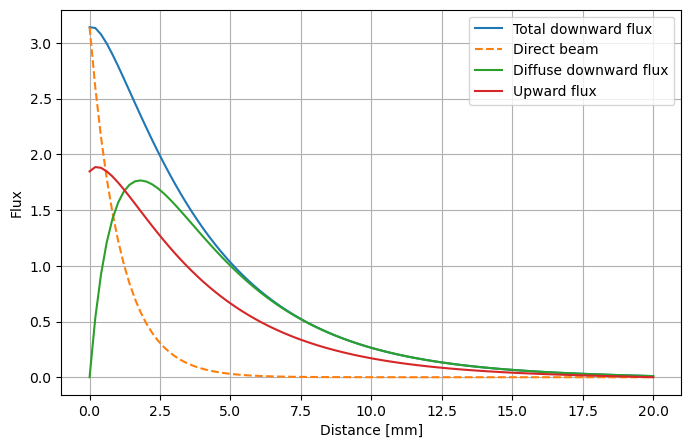

In [84]:
plt.figure(figsize=(8,5))

plt.plot(real_distance_test_arr, F_down_total, label="Total downward flux")
plt.plot(real_distance_test_arr, F_down_direct, "--", label="Direct beam")
plt.plot(real_distance_test_arr, F_down_diffuse, label="Diffuse downward flux")
plt.plot(real_distance_test_arr, F_up, label="Upward flux")

plt.xlabel("Distance [mm]")
plt.ylabel("Flux")
plt.legend()
plt.grid()

plt.show()